In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../datasets/Salary_dataset.csv", )
df = df.drop(columns=["Unnamed: 0"])

df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


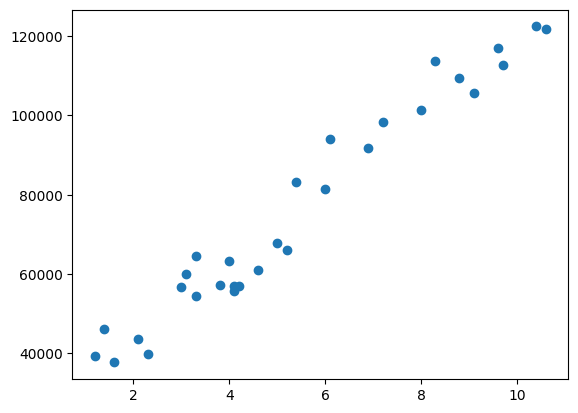

In [68]:
plt.scatter(df['YearsExperience'], df['Salary'])

In [104]:
class CustomLR:
    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        X_mean = X_train.values.mean()
        y_mean = y_train.values.mean()
        n = len(X_train)
        covariance = 0
        variance = 0
        for i in range(n):
            x_i = X_train.values[i]
            y_i = y_train.values[i]
            covariance += ((x_i-X_mean) * (y_i-y_mean))
            variance += (x_i-X_mean)**2
        self.m = covariance/variance
        self.b = y_mean - self.m * X_mean

        print(f"coef_: {self.m}, intercept_: {self.b}")

    def predict(self, X_test):
        n = len(X_test)
        predictions = []
        for i in range(n):
            predictions.append(float((self.m*X_test.values[i]) + self.b))

        return np.array(predictions)

In [113]:
from sklearn.model_selection import train_test_split

y = df['Salary']
X = df['YearsExperience']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = CustomLR()
lr.fit(X_train, y_train)

coef_: 9423.815323030976, intercept_: 24380.201479473704


In [114]:
lr.predict(X_test)

array([115791.21011287,  71499.27809463, 102597.86866063,  75268.80422384,
        55478.79204548,  60190.69970699])

In [116]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
X_train_2d = X_train.values.reshape(-1,1)
model.fit(X_train_2d, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [117]:
X_test_2d = X_test.values.reshape(-1,1)
preds = model.predict(X_test_2d)

In [118]:
preds

array([115791.21011287,  71499.27809463, 102597.86866063,  75268.80422384,
        55478.79204548,  60190.69970699])

In [119]:
print(model.coef_)
print(model.intercept_)

[9423.81532303]
24380.201479473704
